# **Home Exam - Deep Learning for Data Science**       
## **<u>Name</u>** : Mellissa Ghandour      
## **<u>ID</u>** : 326541521       

## **Section A — Model Comprehension – DCGAN Model**

### <u>**Question A1 — Architecture Understanding**</u>       
DCGAN (Deep Convolutional GAN) is a convolutional adaptation of the original Generative Adversarial Network (GAN) framework, introduced to stabilize GAN training using specific architectural constraints. It acts like an AI artist and critic playing a game to create realistic images. Like a standard GAN, it consists of two neural networks trained simultaneously in a minimax game: a Generator G, which attempts to synthesize realistic images from random noise, and a Discriminator D, which tries to distinguish real images from generated ones by outputting a scalar score (typically interpreted as a probability). The main contribution of DCGAN is the use of deep convolutional architectures together with carefully designed constraints that improve training stability.

1. The generator: 
The generator receives random noise vector from a latent space $ 𝑧 ∼ 𝑝(𝑧) $(fixed length, typically 100 dimensional, sampled from a normal distribution) and transforms it into a synthetic (fake/fabricated) but realistic image in the pixel space. The transformation to image happens through a sequence of learnable upsampling operations. First, the noise vector is projected into a small spatial representation and reshaped into a low-resolution feature map (e.g., 4×4 with many channels). From there, the generator applies several fractionally-strided (transposed) convolution layers that progressively increase the spatial resolution (e.g., 4×4 → 8×8 → 16×16 → 32×32 → 64×64). These layers learn how to upsample while refining feature representations. DCGAN follows strict activation rules:
   - ReLU is used in all intermediate generator layers.
   - Batch Normalization is applied in most layers to stabilize activation distributions and improve gradient flow.
   - The final layer uses a Tanh activation to produce pixel values in the range $[−1,1].$

The architecture is almost entirely convolutional — fully connected hidden layers are removed (except for the initial projection), which helps preserve spatial structure and stabilize training.

2. The discriminator: 
The discriminator mirrors the generator’s structure but then performs the reverse operation. It receives an image (real or generated) and processes it through a stack of strided convolution (Conv) layers that reduce spatial dimensions while increasing feature depth. Instead of using fixed pooling operations, DCGAN replaces pooling with strided convolutions used to progressively downsample the input image, improving representational flexibility and stability. LeakyReLU activations are applied to maintain gradient flow, and Batch Normalization is used in intermediate layers (but not typically in the first layer). The final layer outputs a single scalar representing the probability that the input image is real (using a sigmoid activation).

During training, both networks are optimized oppositionally. The generator improves by receiving gradients that flow through the discriminator, meaning its updates depend on how successfully it fools the discriminator. This adversarial feedback loop forces the generator to progressively produce more realistic images, while the discriminator learns increasingly refined features to distinguish real from fake samples. The architectural constraints in DCGAN—such as removing fully connected layers and pooling—help stabilize this dynamic by preserving spatial structure and reducing optimization instability.

A defining architectural principle of DCGAN is the use of an almost entirely convolutional structure. Except for the initial projection layer in the generator, fully connected hidden layers are removed. This design preserves spatial structure and contributes to more stable adversarial training. Replacing pooling with strided convolutions allows the network to learn its own downsampling operations instead of relying on fixed functions, improving representational flexibility.

Overall, data flows as:
latent noise → generator (upsampling blocks) → synthetic image → discriminator (downsampling blocks) → scalar real/fake score/probability.

The discriminator architecture is roughly the mirror of the generator, forming a symmetric upsampling–downsampling structure, with both networks implemented using all-convolutional architectures without fully connected hidden layers.

The following Figure: All-convolutional generator used in DCGAN (architecture diagram from the paper):

Figure 1: 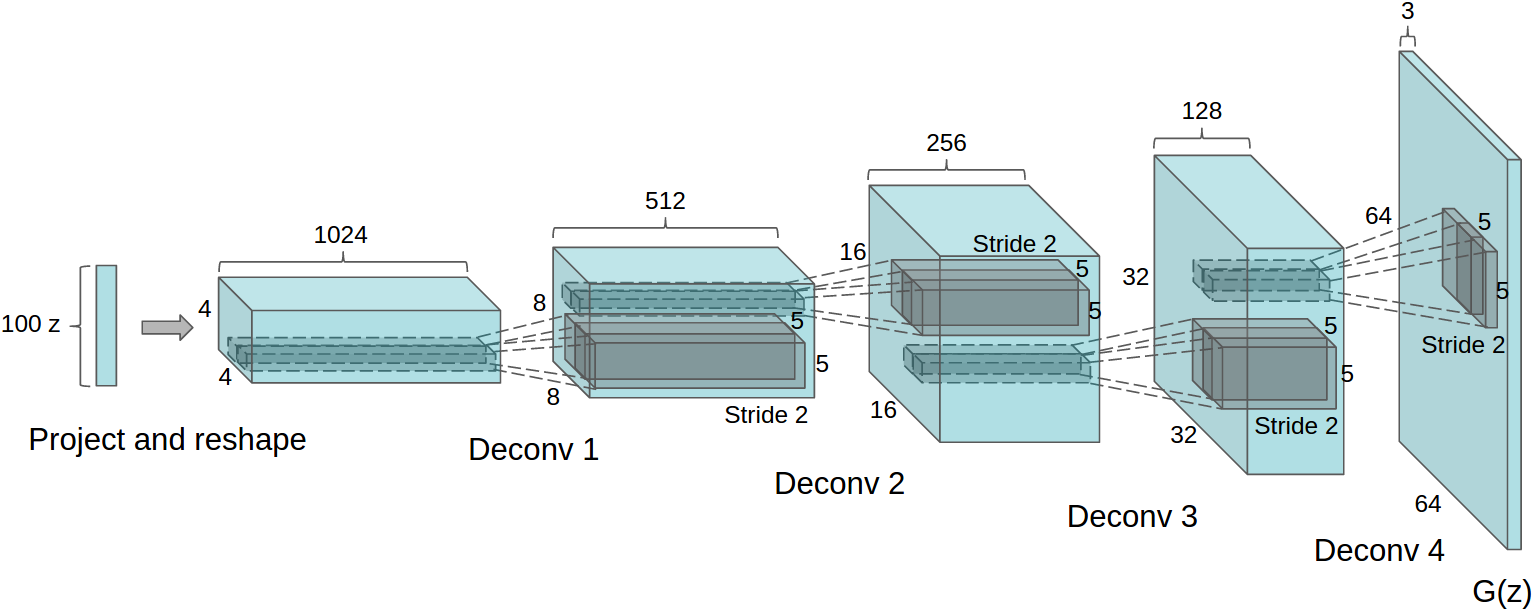

### <u>**Question A2 — Motivation and Improvements**</u>   
Early GAN architectures were known to be highly unstable, difficult to train and highly sensitive to architectural and optimization choices. Common failure modes included: unstable volatile behavior; sensitivity to hyperparameters;  discriminator domination (leading to vanishing gradients for the generator); and mode collapse, where the generator produces limited diversity. Alec Radford (in the paper) hypothesized that many of these issues/instability were caused not by the adversarial objective itself, but by architectural design choices.

DCGAN introduces a set of architectural constraints specifically aimed at improving training stability:

One of the first things the authors changed was how the model handles resolution. **Instead of using fixed pooling layers** for spatial downsampling, which is a fixed calculation, the discriminator employs strided convolutions, while the generator uses fractionally-strided (transposed) convolutions for upsampling. This modification makes resolution changes learnable operations rather than deterministic ones. As a result: 
   - The model can adapt how spatial information is aggregated or expanded
   - Gradients propagate more consistently through learned filters.
   - The networks maintain better control over spatial feature hierarchies. 
   
This improves stability by avoiding abrupt information loss caused by fixed pooling.

The authors also **integrated Batch Normalization into most layers** of both networks (with typical exclusions at the generator output and discriminator input). Rather than simply normalizing to zero mean and unit variance, BatchNorm: 
  - Standardizes activations using batch statistics 
  - Introduces learnable scale and shift parameters
  - Reduces sensitivity to initialization
  - Prevents gradients from exploding or vanishing
    
In adversarial training, where the generator and discriminator continuously change each other’s gradients, maintaining well-conditioned activation distributions is critical. Experimentally, the authors observed that removing BatchNorm significantly destabilized training.

They also **Removed the fully connected hidden layers** and decided to make the DCGAN architectures almost entirely convolutional with an all-convolutional design. Except for the initial projection in the generator, fully connected hidden layers are removed. This design:
  - Preserves spatial structure throughout the network
  - Reduces parameter sensitivity
  - Encourages hierarchical feature learning
  - Improves generalization across image regions
    
Fully connected layers tend to destroy spatial correlations and introduce large parameter matrices that can amplify instability in adversarial setups.

And decided that **carefully selected activation functions (ReLU in G, LeakyReLU in D, Tanh output)** can ensure consistency between real and generated samples, so the DCGAN uses:
  - ReLU in the generator (intermediate layers)
  - LeakyReLU in the discriminator
  - Tanh in the generator output layer

ReLU enables strong positive-gradient flow in the generator, helping deep feature construction. LeakyReLU prevents inactive units in the discriminator and ensures gradients remain informative even for negative activations. Tanh constrains output pixel values to the normalized image range [−1,1].

### Summary:
Together, these architectural constraints significantly reduce training instability. Rather than altering the adversarial objective, DCGAN demonstrates that careful architectural design alone can transform GAN training from fragile to robust. The empirical results in the paper show that these constraints enable stable training on large-scale image datasets, such as LSUN Bedrooms, where earlier GAN variants failed to converge reliably.

### <u>**Question A3 — Design Choice Critique**</u>   
In my opinion one of the most critical architectural constraints introduced in DCGAN is the **extensive use of Batch Normalization in both the generator and the discriminator** (with typical exclusions at the generator output and discriminator input).

Batch Normalization plays a particularly important role in adversarial training. In GANs, the generator and discriminator updated alternately, and because each network continuously adapts to the other, the distribution of intermediate activations constantly shifts. This dynamic interaction makes optimization highly unstable. Batch Normalization was introduced to help regulate this instability by normalizing intermediate activations using batch statistics  across layers and introducing learnable scaling parameters. As a result, gradients remain better conditioned, and deeper networks become trainable.

<u>If Batch Normalization were removed, several failure modes would likely emerge:</u> The network would likely become significantly more unstable. Activations, in each layer, could grow or shrink uncontrollably because the activations are not normalized, making gradients noisy or vanishing(Unstable gradient dynamics). The discriminator might quickly overpower the generator, causing mode collapse or preventing meaningful learning. The authors explicitly report that removing BatchNorm caused unstable behavior during training, demonstrating its importance.

- Discriminator dominance:If the discriminator learns too quickly due to uncontrolled activation scaling, it can saturate and provide near-zero gradients to the generator. This prevents meaningful generator updates.

- Mode collapse: When gradients become unstable or poorly conditioned, the generator may converge to producing a limited set of outputs that consistently fool the discriminator, reducing diversity.

- In practice, without BatchNorm, the 'All-Convolutional' layers struggle to coordinate. The paper shows that without this layer-wise normalization, the model often fails to collapse into a single mode—it just fails to learn any recognizable shapes at all.

<u>In summary</u>, Batch Normalization is not merely a regularization technique in DCGAN; it is a stabilization mechanism that enables deep adversarial learning to function reliably. Removing it would likely reintroduce the instability issues that DCGAN was specifically designed to address.

### <u>**Question A4 — Representation Learning**</u>  
The authors argue that DCGAN does not merely generate visually plausible pixels, but instead learns meaningful internal representations of the data distribution, despite being trained without semantic supervision. Since the training process is fully unsupervised, demonstrating this claim requires empirical evidence that the model has captured the underlying "logic" of the visual world.

The authors provide four main pieces of evidence:
1. <u>Structured latent space through smooth interpolation</u>: memorization or smooth transition?
The first evidence comes from linearly interpolating between two random points in the latent space, the generated images transform smoothly and coherently rather than abruptly. For example, in the LSUN bedroom experiments, room geometry, lighting, layout and furniture transition gradually instead of "jumping" from one bedroom to another.
This is critical because it suggests the generator has learned a continuous data manifold rather than memorizing training samples(overfitting). If the model were memorizing images, small changes in latent space would produce discontinuous or nonsensical outputs. Instead, nearby latent vectors correspond to semantically similar images, indicating structured representation learning.

Figure 2: Smooth interpolation demonstrating continuity of the learned manifold.

2. <u>Linear Semantic Arithmetic in latent space</u>- using arithmetics to manipulate image features:
Perhaps the most famous result is that DCGAN organizes concepts linearly. By performing simple vector math (arithmetic) on the noise vectors—specifically “man with glasses” − “man without glasses” + “woman without glasses” ≈ “woman with glasses" — the generator produces a “woman with glasses”. This indicates that high-level attributes such as gender and the presence of glasses are encoded along meaningful, approximately linear directions in the latent space. Such behavior strongly indicates that the model has learned disentangled semantic factors rather than arbitrary noise-to-pixel mappings.

Figure 3: Vector arithmetic showing semantic attribute manipulation

3. <u>Transferable discriminator features</u>- what does the discriminator actually looks at in the image?
Beyond generation, the authors further analyzed the Discriminator’s internal layers. 
By extracting intermediate convolutional features and using them as input to a simple linear classifier, they achieve competitive performance on supervised tasks.
This shows that the discriminator learns hierarchical visual features — from simple edges to complex objects—to distinguish "realness," even though it was never told what those objects are. Rather than relying on superficial artifacts to distinguish real from fake images, it develops structured feature representations similar to those learned in supervised convolutional networks.

4. <u>Interpretable filters and controlled manipulation</u> what happens to the result when deleting identified filters?
The paper also visualizes generator and discriminator filters. Certain filters specialize in detecting recurring visual elements such as windows, beds, or facial components. In controlled experiments, removing filters associated with specific objects (e.g., windows) systematically alters the generated images, replacing windows with semantically consistent alternatives such as walls while preserving overall scene structure.
This indicates that internal feature channels correspond to meaningful visual concepts

Figure 4: Visualization of filters specialized to specific object detectors.

<u>Why This Is Non-Trivial</u> 
DCGAN is trained without labels, annotations, reconstruction objectives, or explicit representation-learning losses. Its only supervision signal is whether an image appears real or generated.

Despite this minimal objective, the model organizes its latent space coherently, learns hierarchical feature representations, and develops transferable visual features. The emergence of semantic structure purely from adversarial training demonstrates that the GAN objective itself can induce meaningful unsupervised representation learning, extending beyond simple image synthesis.



Figure 2 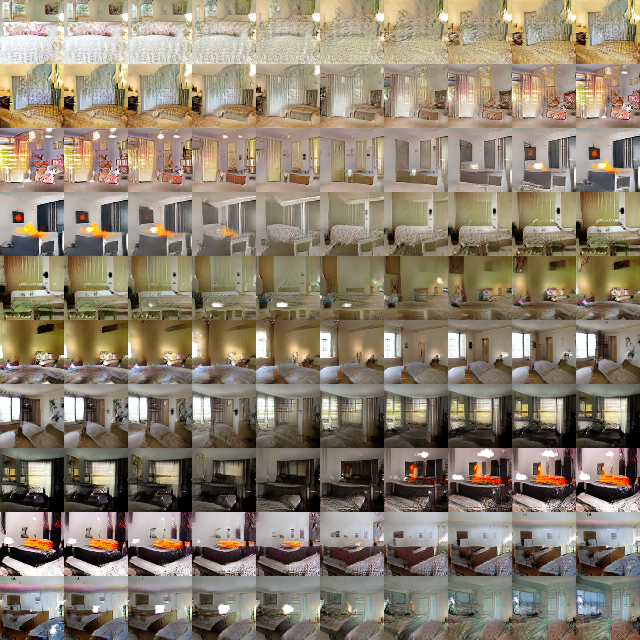

Figure 3 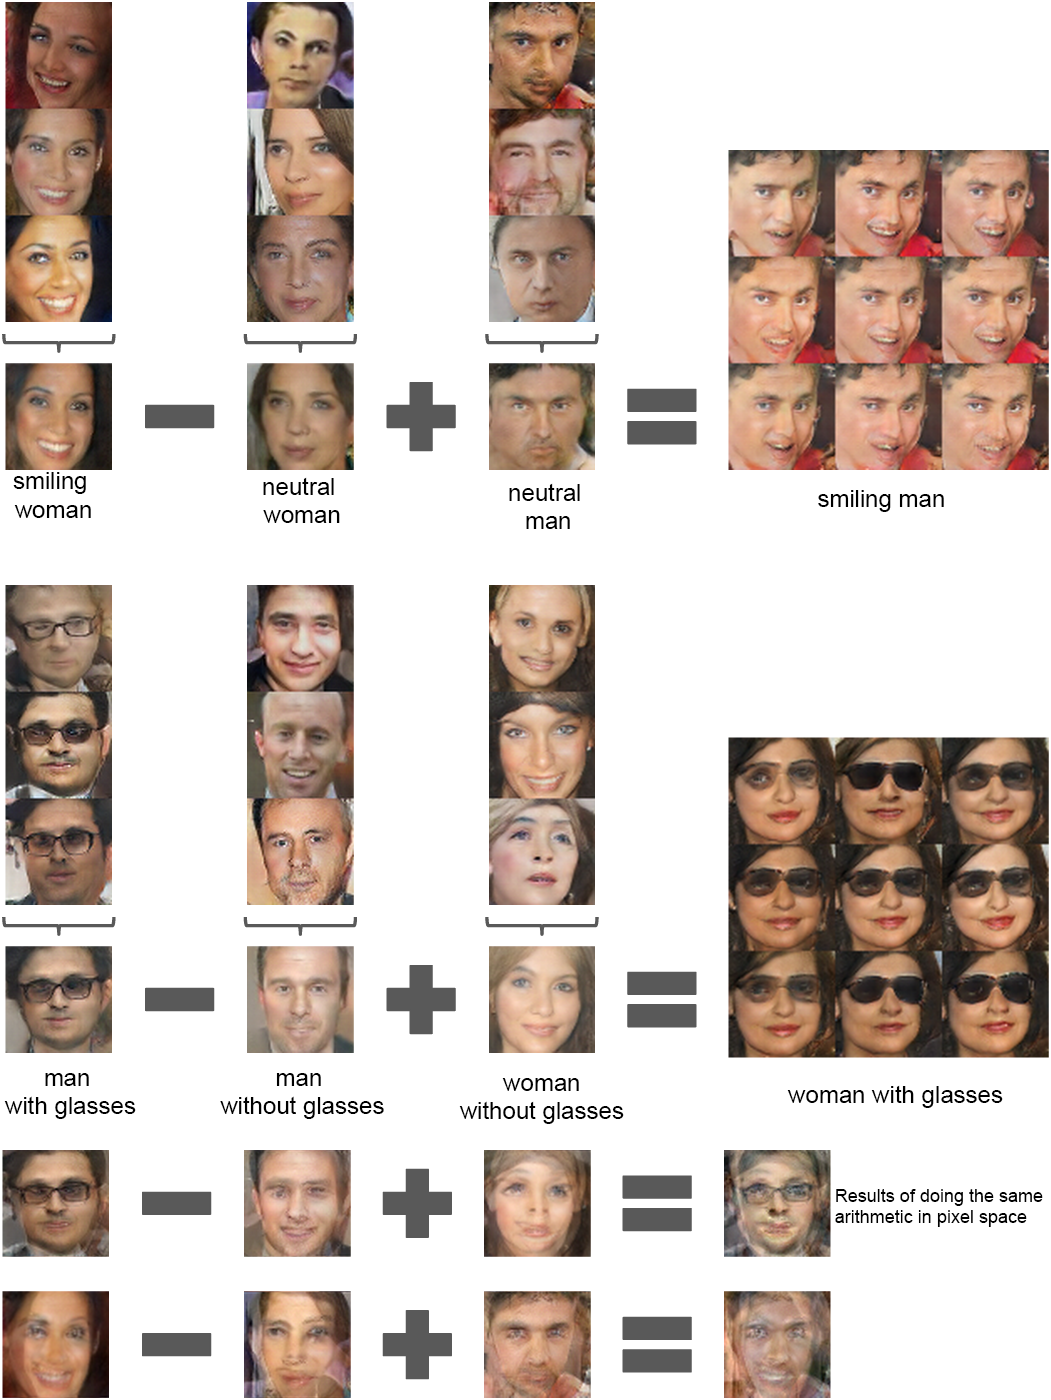

Figure 4 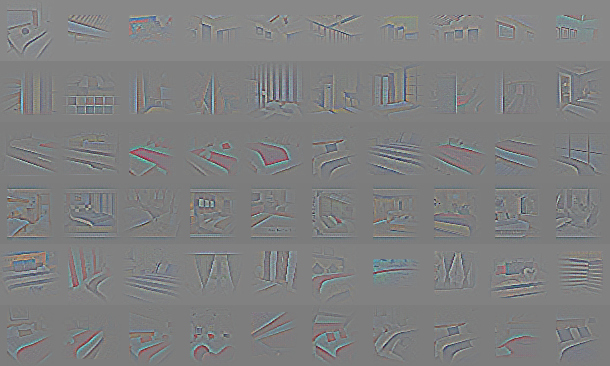

## **Section B - Implementation of 1D CNN**
### <u>**Question B1 — Implement the forward pass**</u>  
- step 1: fill the missing in_features(from B2): *self.fc1 = nn.Linear(in_features=46 * C2, out_features=25)*
- step 2: forward order: *conv1 → ReLU → pool → conv2 → ReLU → flatten → fc1 → ReLU → fc2*
 
Completed the forward() function:

**code**


In [2]:
#given:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN1D(nn.Module):
    def __init__(self, C1=8, C2=16):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=C1, kernel_size=5, stride=1, padding=0)
        self.pool  = nn.MaxPool1d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv1d(in_channels=C1, out_channels=C2, kernel_size=3, stride=1, padding=0)

# assignment to do: 1) compute the in_features for fc1, 2)implement the forward pass of the network 
        # From B2: after conv2 we have length 46, with C2 channels
        self.fc1 = nn.Linear(in_features=46 * C2, out_features=25)
        self.fc2 = nn.Linear(in_features=25, out_features=1)

    def forward(self, x):
        # x: [B, 1, 100]
        x = self.conv1(x)          # [B, C1, 96]
        x = F.relu(x)
        x = self.pool(x)           # [B, C1, 48]
        x = self.conv2(x)          # [B, C2, 46]
        x = F.relu(x)

        x = torch.flatten(x, start_dim=1)  # [B, C2*46]
        x = self.fc1(x)           # [B, 25]
        x = F.relu(x)
        y = self.fc2(x)           # [B, 1]
        return y


**example run**

In [3]:
#example run:
model = SimpleCNN1D(C1=8, C2=16)
x = torch.randn(4, 1, 100) # batch=4
y = model(x)
print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: torch.Size([4, 1, 100])
y shape: torch.Size([4, 1])


**output**: 
- x shape: torch.Size([4, 1, 100])
- y shape: torch.Size([4, 1])

**short explanation:**
- This network applies Conv1D + ReLU to extract local patterns, then MaxPool reduces the length by half (adds shift tolerance), then a second Conv1D + ReLU extracts higher-level features. After flattening, FC1 maps the features to 25 hidden units, and FC2 outputs a single scalar per sample.

**how i tested it:**
- I verified the shape at each stage (Conv1 → 96, Pool → 48, Conv2 → 46), checked that flatten produces size $46*C2$, and ran a forward pass with random input to confirm the model runs without shape errors and returns output of shape $[B,1]$




### **<u>Question B2 — Shape reasoning</u>**
Given: input tensor shape is $[B, 1, 100]$ (batch, channels, length)
- step 1: **After Conv1**- 
Conv1 parameters: **kernel $K$ =5, stride $S$ =1, padding $P$ =0 (valid)**
For 1D conv, the output length is: $Lout​=⌊(Lin​+2P−K)/​S⌋+1$
Here: 
   - $Lin=100,P=0,K=5,S=1$
   - $Lout=⌊(100+2*0−5)/1⌋ + 1 = 96$ 
   - Channels become C1 (because out_channels = C1)
   - After Conv1: $[B, C1, 96]$

- step 2: **After MaxPool1d**- 
MaxPool params: **kernel $K$ =2, stride $S$ =2, padding $P$ =0 
   - $Lin=96,K=2,S=2$
   - $Lout​=⌊(96​+2*0−2)/​2⌋+1 = 48$
   - $After Pool: [B, C1, 48]$

- step 3: **After Conv2**-
Conv2 params: **kernel $K$ =3, stride $S$ =1, padding $P$ =0  (valid)
Now $Lin=48$
   - $Lout​=⌊(48​+2*0−3)/​1⌋+1 = 46$
   - Channels become C2.
   - After Conv2: $[B, C2, 46]$

- step 4: **After Flatten**-
Flatten turns $[B, C2, 46]$ into $[B, C2·46]$
   - After Flatten: $[B, 46·C2]$
   - Final (what FC1 needs)
     - flatten_dim = $46 * C2$
   - FC1 in_features = $46 * C2$

So FC1 must be:
   - nn.Linear(in_features= $46*C2$, out_features $=25$)
   

### **<u>Question B3 — Intuition: response to a sinusoid </u>**
Given: the input signal $x[t] = sin(2πft/100)$ for $t = 0,…,99$
1. convolutional filter that would respond strongly to a sinusoid of some frequency:
   - Option A: Edge/difference detector (length 3) → $[−1, 0, 1]$
      - <u>Why it responds:</u> Responds strongly when the signal changes quickly (rapid change) (high slope/edges). It measures “difference” between neighbors. A sinusoid with faster changes (higher frequency) creates larger local differences → bigger response.
   - Option B: smoothing/averaging (length 5) → $[1, 1, 1, 1, 1] * 1/5$
      - <u>Why it responds:</u> Responds strongly to slow variations (low frequency), suppresses noise/high-frequency. It averages nearby values, so it keeps slow trends (low frequency) and cancels fast oscillations (high frequency).
2. If frequency f increases, what happens to activations?
   - 1: Smoothing/averaging filter(responds less): As f increases, the sinusoid flips sign more quickly inside the averaging window → positives and negatives cancel out in averege. So the activation magnitude generally decreases (it “filters out” high frequency), response tends to decrease as f increases.
   - 2: Difference/edge-detecting filter(responds more- up to limits): As f increases, the signal changes faster from sample to sample → neighboring differences grow. So the activation magnitude generally increases (more “edge-like” changes), until extremely high frequencies where sampling effects can distort things, response tends to increase for higher f until very high f where discretization/aliasing effects can complicate things.
3. Why max pooling (2→1) reduces sensitivity to small phase shifts?
- MaxPool with kernel 2 takes the maximum in each local (small) window. If the sinusoid shifts slightly in time (small phase shift), the local peak may move from one index to the neighbor—but it often stays inside the same 2-sample window, so the max stays similar → more shift-invariant/less phase-sensitive.
   - Result: pooling makes the representation more shift/phase tolerant (less sensitive to tiny shifts).

## **Section C - Implementation of 1D CNN**
### **<u>Question C1 — Model understanding</u>**
1) **The role of the CNN backbone in CCNet**: In CCNet, the CNN backbone (ex- ResNet-101) serves as the primary dense feature extractor, designed to capture local context, spatial hierarchies, and low-level visual details from input images. It converts (reduces) the input image into a high-level semantic feature map while preserving enough spatial resolution for dense prediction. CCNet then uses this feature map as the “raw material” for context reasoning. The downsampling stages are replaced with dilated convolutions to maintain a large receptive field without excessively reducing spatial dimensions (usually 1/8 of the input) without the information loss that comes from standard pooling layers. This ensures that the network captures rich semantic information while keeping fine spatial details required for accurate segmentation.
   - In other words: the backbone provides strong local evidence, acting as a foundational encoder; CCNet builds global context (reasonings) on top of it, by downstream tasks like object detection or segmentation. 
2) **What the Criss-Cross Attention (CCA) module does**: The Criss-Cross Attention (CCA) module enhances each pixel’s representation by aggregating contextual information from all pixels in the same row and the same column — its “criss-cross” path. Instead of computing full global attention (which is computationally expensive), CCA efficiently captures long-range dependencies using this structured attention pattern, so a pixel can use context far away without attending to all pixels at once. The paper highlights that through query, key and value projections, the module computes attention weights which determine which spatial locations are most relevant. The weighted aggregation of these features improves semantic consistency of predictions.

3) **How CCNet combines local features and global contextual information**: First, the CNN (convolutional) backbone extracts local features such as edges, textures, and object parts. The CCA module then refines these features by injecting long-range contextual dependencies. By applying the criss-cross attention module recurrently (RCCA), information propagates globally (across the entire image), enabling each position effectively gathers dense global context(information from all pixels).The final representation therefore integrates detailed local structure with global semantic understanding, enabling more accurate and coherent predictions.
   - Key point: CCNet doesn’t replace local CNN (convolutional) features — it strengthens them by adding structured global context and fusing both sources of information.

### **<u>Question C2 — Controlled modification task </u>**
**Modified Model**

In [7]:
import torch
import torch.nn as nn

class CCNetBinary(nn.Module):
    '''
    Modified CCNet for global binary image-level classification.
    The Backbone and RCCA module remain unchanged.
    Only the segmentation head is replaced by a global classification head.
'''
    def __init__(self, backbone: nn.Module, rcca_module: nn.Module, in_channels: int):
        super().__init__()

        # Keeping original components unchanged
        self.backbone = backbone
        self.rcca = rcca_module

        # Replace segmentation head with global classification head
        self.global_pool = nn.AdaptiveAvgPool2d(1) # Global Average Pooling
        self.classifier = nn.Linear(in_channels, 1) # Single logit output

    def forward(self, x):
        # Step 1: Extract local features using backbone
        features = self.backbone(x)          # [B,C,H,W]

        # Step 2: Refine features with Criss-Cross Attention
        features = self.rcca(features)       # [B,C,H,W]

        # Step 3: Aggregate global spatial information
        pooled = self.global_pool(features)  # [B,C,1,1]
        
        # Step 4: flatten pooled features to vector 
        pooled = pooled.view(pooled.size(0), -1)  # [B,C]

        # Step 5: Output single binary logit per image
        logits = self.classifier(pooled)     # [B, 1]

        return logits


**Loss Function**

In [12]:
criterion = nn.BCEWithLogitsLoss() # Binary Cross-Entropy with Logits Loss is suitable for binary classification tasks and combines a sigmoid layer with the binary cross-entropy loss in a single class. It is numerically more stable than using a plain Sigmoid followed by a BCELoss.

**test run**

In [15]:
if __name__ == "__main__":
    # Dummy backbone and RCCA for testing
    backbone = nn.Identity()
    rcca = nn.Identity()
    # Suppose backbone outputs [B, 64, H, W]
    model = CCNetBinary(backbone, rcca, in_channels=3)

    # Dummy input
    x = torch.randn(4, 3, 64, 64)  # [B, C, H, W]

    # Forward pass
    logits = model(x)
    print("Output shape:", logits.shape)

    # Dummy targets
    targets = torch.randint(0, 2, (4,)).float().unsqueeze(1)

    criterion = nn.BCEWithLogitsLoss()
    loss = criterion(logits, targets)

    print("Loss:", loss.item())

    print("Test passed :)")   # 👈 Add it here

Output shape: torch.Size([4, 1])
Loss: 0.7180889844894409
Test passed :)


**output**: 
- Output shape: torch.Size([4, 1])
- Loss: 0.7180889844894409
- Test passed :)

**short explanation:**
- The modified model keeps the backbone and RCCA modules unchanged. In the forward pass, the input image is processed by the backbone to extract feature maps, then refined using RCCA. Global Average Pooling reduces the spatial dimensions to a single feature vector per image, which is passed through a linear layer to produce one binary logit per image.

**how i tested it:**
- I tested the implementation using dummy backbone and RCCA modules (nn.Identity) and random input tensors of shape $[B, C, H, W]$. I verified that the model output has shape $[B, 1]$ and computed BCEWithLogitsLoss using randomly generated binary targets to confirm that the forward pass and loss function execute without errors.




#### <u>**what you changed and why these changes are sufficient?**</u>
To adapt CCNet for image-level binary classification while keeping the backbone and Recurrent Criss-Cross Attention (RCCA) modules intact, I replaced the dense segmentation head with a global classification head. The backbone continues to extract high-level local features, and RCCA still enriches each pixel with long-range contextual information across its row and column. Instead of producing a per-pixel prediction map, I applied Global Average Pooling to collapse the spatial dimensions into a single feature vector per image, which is then passed through a linear layer to output one logit. This modification is sufficient because the backbone and attention modules already generate strong context-aware representations; only the prediction objective changes. Since the task shifts from dense segmentation to image-level classification, I replaced the pixel-wise Cross-Entropy loss with BCEWithLogitsLoss. Additionally, the ground-truth supervision must be adapted from 2D segmentation masks to a single binary label per image, which can be derived by checking whether the target class appears anywhere in the mask. These changes fully align the architecture and supervision with the new binary classification objective while preserving CCNet’s contextual reasoning capability.

### **<u>Question C3 — Reasoning about attention </u>**
1. Why might Criss-Cross Attention still be useful for a global image-level prediction?
   - Even though the final task is now image-level binary classification, Criss-Cross Attention (RCCA) remains useful because it enriches the feature map before spatial information is collapsed by global pooling. The key idea is that when we apply Global Average Pooling, we are not pooling/aggregating raw local features — we are pooling features that already encode long-range dependencies across the image. Object presence is often not determined by a single local patch. It may depend on combining evidence from multiple distant regions (for example,small object parts appearing in different areas or partially occluded structures). RCCA allows spatial locations to exchange information along rows and columns, and with recurrence, context effectively propagates globally. As a result, the pooled representation becomes more semantically consistent and context-aware, which improves the reliability of the final binary prediction.
2. What information does the attention module capture that a purely convolutional network might miss?
   - A purely convolutional network captures information through local receptive fields. Although the receptive field grows with depth or dilation, interactions between far-apart regions remain indirect and hierarchical.Criss-Cross Attention explicitly models long-range dependencies. Each spatial position can directly attend to pixels in its entire row and column, and through recurrence, information flows across the entire image. This allows the model to:
     - Relate distant but semantically similar regions
     - Connect separated object parts
     - Use global context to resolve local ambiguity
   - A standard CNN would require many stacked layers to approximate this behavior, whereas attention provides a more direct mechanism for global reasoning.
3. One potential downside of keeping the attention module for this new task:
   - The main downside is computational cost. RCCA increases memory usage and computation due to the attention operations and recurrence loops. Since the final task produces a single global label and spatial dimensions are eventually collapsed by pooling, dense pixel-level contextual modeling may be more than necessary. 
     - In other words, while attention provides richer representations, it may be overkill for a simple presence/absence classification task, making the model heavier and slower than a simpler backbone + pooling classifier.

### **<u>Question C4 (Bonus) — Optional extension </u>** - (Bounding Box instead of Segmentation)
1. <u>What parts of the model would need to change?</u> 
   - The backbone and the RCCA (Criss-Cross Attention) module do not need to change, since they already extract strong local and global contextual features. The modification would be in the prediction head and the supervision scheme. that produces a dense per-pixel class map, we would replace it with a bounding box regression head that outputs box coordinates. This head would operate on the context-enriched feature map after RCCA. Depending on the design, we could apply global pooling and regress one box per image (for single-object assumption), or Add a small detection-style head (ex- convolutional layers predicting box coordinates from spatial features). The loss function would also change from pixel-wise cross-entropy (segmentation) to a regression loss such as Smooth L1 (Huber) or L1/L2 loss for bounding box coordinates.
2. <u>What kind of output representation you would use?</u>
   - The boundinf boc can be represented as a 4-dimensional vector per image: $(xmin, ymin, xmax, ymax)$
   - or alternatively: $(xcenter, ycenter, width, height)$
   - The coordinates should be normalized to $[0,1]$ relative to image dimensions to improve numerical stability during training. If required, an additional confidence score could be predicted, resulting in an output tensor of shape: $[B,4]or[B,5]$ instead of the dense segmentation output $[B,C,H,W]$.
3. <u>One challenge this introduces compared to segmentation:</u>
   - A key challenge is the reduction in supervision density. Segmentation provides pixel-level supervision across the entire object mask, supplying dense spatial gradients during training. In contrast, bounding box regression compresses all spatial structure into only four numbers. This makes training more sensitive to localization errors — even small coordinate shifts can significantly reduce IoU (Intersection over Union). As a result, optimization can become less stable, particularly for small, occluded, or irregularly shaped objects.
     - In other words, segmentation teaches the model precise object boundaries at pixel resolution, whereas bounding box regression forces the model to summarize spatial structure into a compact geometric representation.